# Русская гравийная серия как продукт: рост, удержание, география

**Автор:** Царегородский Александр · **Данные:** открытый архив протоколов [gravelseries.ru](https://gravelseries.ru/results) + справочник площадок, собранный по сайтам и каналам гонок

Русская гравийная серия (РГС) объединяет независимых организаторов гревел-гонок: у них общий рейтинг и общий календарь.
Серия рассматривается **как продукт**: гонщик — пользователь, старт — сессия, сезон — период.

**Заказчик** — объединение организаторов серии. **Решение**, которое он принимает: куда вкладывать усилия между сезонами —
в привлечение новичков, в их удержание, в календарь или в связку этапов между собой.

**Период анализа — 2023–2026.** Серия официально запущена в 2025 году ([gravelo.ru](https://velo.gravelo.ru/russkaya-gravijnaya-seriya-2026/)),
но тот же набор гонок (6–8 этапов) проходит с 2023-го, и сайт серии считает рейтинг за эти годы задним числом.
2018–2022 — одна-две гонки в год, сравнивать их с серией некорректно; эти годы используются только как предыстория
и чтобы отличить настоящих новичков от вернувшихся ветеранов.

Вопросы:
1. **Календарь и география.** Где и когда проходят этапы? Как это связано с тем, кто куда ездит?
2. **Рост.** За счёт чего растёт аудитория: новичков, вернувшихся, частоты стартов?
3. **Удержание.** Сколько новичков возвращается на следующий сезон?
4. **Aha-момент.** Что в первом сезоне отличает вернувшихся? Как это проверить экспериментом?
5. **Точки входа и экосистема.** После каких этапов новички возвращаются чаще? Как пересекаются аудитории?
6. **Дистанции и трассы.** Переходят ли с короткой дистанции на длинную? Сходы, скорость.

> Пайплайн: `extract` (API сайта) → `transform` (очистка, сведение гонщиков) → `load` (DuckDB + справочник площадок + SQL-витрины) → этот ноутбук.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.formula.api as smf
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

from gravel import viz
from gravel.load import connect
from gravel.transform import name_keys
from gravel.viz import BLUE, ORANGE, AQUA, GRAY, TEXT, TEXT_2, TEXT_3, SURFACE

viz.setup()
pd.set_option("display.max_columns", 30)
con = connect()
q = lambda sql: con.sql(sql).df()
REGION_COLOR = {"Северо-Запад": BLUE, "Центр": ORANGE}
FROM_YEAR = 2023

## 1. Данные и их качество

**Протоколы.** Архив содержит все протоколы этапов серии и её предшественников. Основная работа — очистка (`src/gravel/transform.py`):

| Проблема | Решение |
|---|---|
| Один человек записан по-разному: «ЦАРЕВ СЕРГЕЙ», «Сергей Царев», «Дима/Дмитрий», с отчеством и без, двойные фамилии | ключ = нормализованные токены (регистр, ё→е, без отчества, уменьшительные → полные имена), алиас для фамилии в скобках |
| 6 форматов времени (`4:15:39`, `03:28:43.32`, `5:03:49,55`, `-`, `?`) | единый парсер → секунды |
| Пустой статус в старых протоколах | с очками → финиш без времени, без очков → сход |
| Километраж указан не везде | парсим из названия; уровень «длинная / короткая» берём из `maxPoints` (1000 = главная дистанция) |
| Места считаются то в абсолюте, то по полу | перцентиль среди финишёров своего пола внутри гонки |

**Справочник площадок** (`data/reference/venues.csv`). В архиве нет ни мест, ни (кроме 2026 года) дат гонок. Для 2023–2026 они собраны вручную
по сайтам и Telegram-каналам организаторов; у каждой строки есть ссылка на источник и флаги точности даты и координат.

In [2]:
q('''
SELECT
    (SELECT COUNT(*) FROM dim_event)                                  AS events_all,
    (SELECT COUNT(*) FROM dim_event WHERE year >= 2023)               AS events_2023_2026,
    (SELECT COUNT(*) FROM fct_result WHERE year >= 2023)              AS results_2023_2026,
    (SELECT COUNT(DISTINCT rider_id) FROM fct_result WHERE year >= 2023) AS riders_2023_2026,
    (SELECT COUNT(*) FROM dim_venue)                                  AS venues_rows,
    (SELECT COUNT(*) FROM dim_venue WHERE coord_quality = 'unknown')  AS venues_no_coords
''')

,events_all,events_2023_2026,results_2023_2026,riders_2023_2026,venues_rows,venues_no_coords
0,34,28,6279,2972,28,2


**Проверка качества сведения гонщиков.** В API рейтингов сайта у гонщиков есть собственные ID (сезоны 2024–2026, 2 450 человек).
Сверяю с ними свои ключи:

In [3]:
raw = Path("../data/raw")
site = pd.DataFrame(
    [(e["racer"]["id"], e["displayName"]) for y in (2024, 2025, 2026)
     for e in json.loads((raw / f"rankings_{y}.json").read_text())["entries"]],
    columns=["site_id", "name"]).drop_duplicates()
site["my_key"] = site["name"].map(lambda n: name_keys(n)[0])

missed = (site.groupby("site_id")["my_key"].nunique() > 1).sum()
merged = site.groupby("my_key")["site_id"].nunique()
merged = merged[merged > 1]
print(f"ID на сайте: {site.site_id.nunique()}")
print(f"Не склеил (один ID сайта -> несколько моих ключей): {missed}")
print(f"Склеил в один ключ несколько ID сайта: {len(merged)}")
site[site.my_key.isin(merged.index)].groupby("my_key")["name"].agg(" | ".join).head(10).to_frame()

ID на сайте: 2450
Не склеил (один ID сайта -> несколько моих ключей): 1
Склеил в один ключ несколько ID сайта: 29


,name
my_key,
александр климов,Климов Александр | Климов Саша
александр шаврин,Шаврин Саша | Шаврин Александр
александр шестаков,Шестаков Александр | Шестаков Саша
алексей голубев,Голубев Алексей Евгеньевич | Голубев Алексей Е...
алексей павлов,Павлов Алексей | Павлов Алёша | ПАВЛОВ Алексей
алексей романов,Романов Алексей | Романов Алексей · №788
баринова екатерина,Баринова Екатерина | Баринова Катя
баронас ромуальдас-игорь,Баронас Ромуальдас-Игорь Витаутович | Баронас ...
бегемотов вячеслав,Бегемотов Слава | Бегемотов Вячеслав | Слава Б...


Не склеился **один** человек из 2 450 (сменилась фамилия). 29 объединений нескольких ID сайта — в основном **дубли, которые пропустил сам сайт**
(«Саша/Александр», «Слава/Вячеслав»); около 8 — настоящие тёзки. Это ~0,3% гонщиков, на агрегаты не влияет.

## 2. Предыстория и выбор периода

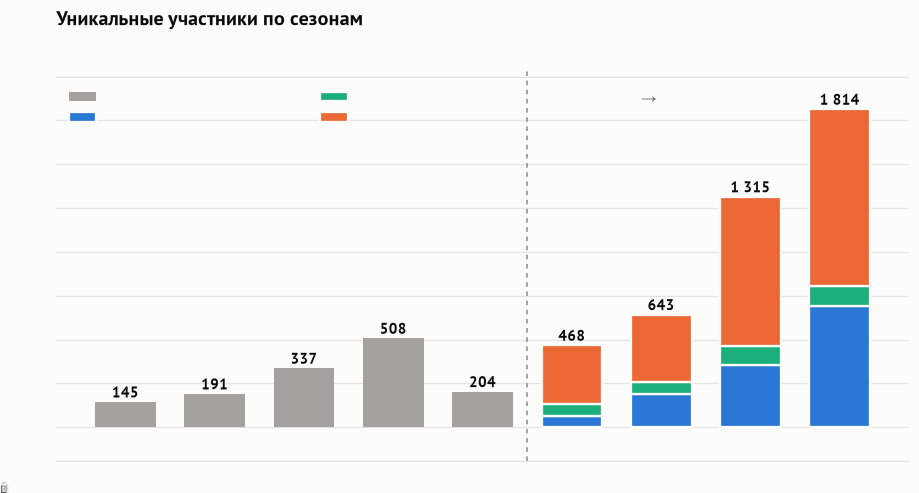

In [4]:
season = q("SELECT * FROM mart_season ORDER BY year")
fig, ax = plt.subplots(figsize=(10, 4.6))
s = season.set_index("year")
hist = s.index < FROM_YEAR
ax.bar(s.index[hist], s.riders[hist], color=GRAY, width=0.68, label="предыстория: 1–2 гонки в год")
parts = [("retained_from_prev", "вернулись с прошлого сезона", BLUE),
         ("resurrected", "вернулись после перерыва", AQUA),
         ("new_riders", "новички", ORANGE)]
bottom = np.zeros((~hist).sum())
for col, label, color in parts:
    ax.bar(s.index[~hist], s.loc[~hist, col], bottom=bottom, color=color, width=0.68, label=label,
           edgecolor=SURFACE, linewidth=1.5)
    bottom += s.loc[~hist, col].values
for x, total, ev in zip(s.index, s["riders"], s["n_events"]):
    ax.text(x, total + 25, f"{total:,}".replace(",", " "), ha="center", color=TEXT, fontsize=10, weight="bold")
    ax.text(x, -150, f"{ev} эт.", ha="center", color=TEXT_3, fontsize=8.5)
ax.axvline(FROM_YEAR - 0.5, color=TEXT_3, lw=1, ls=(0, (3, 3)))
ax.text(FROM_YEAR - 0.42, s.riders.max() * 1.02, "период анализа →", color=TEXT_2, fontsize=9.5)
ax.set_ylim(-190, s["riders"].max() * 1.12)
ax.set_xticks(s.index)
ax.set_title("Уникальные участники по сезонам")
viz.subtitle(ax, "С 2023 года проходят те же 6–8 гонок; с 2025-го они официально объединены в серию")
ax.legend(loc="upper left", ncols=2, bbox_to_anchor=(0, 0.98), fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", " ") if v >= 0 else ""))
viz.save(fig, "01_history"); plt.show()

- **2018–2022** — одна-две гонки в год: Gravel King (2018) и [«Обратная сторона дороги»](https://shchepinov.pro/reverse-race-5/) под Петербургом (2019–2021),
  в 2022-м — Спорт-Марафон Фест и SHULZ. Это другой продукт: одно событие, а не серия.
- **С 2023 года** календарь стабилен: те же 6–8 гонок каждый сезон. Поэтому все метрики ниже считаются **с 2023 года**.
  Ранние годы используются только чтобы не считать новичком ветерана «Обратной стороны», вернувшегося в 2023-м.

## 3. Календарь и география: серия — это два региональных кластера

In [5]:
venues = q('''
SELECT e.year, e.series_key, e.event_name, v.*
FROM dim_venue v JOIN dim_event e ON e.event_id = v.event_id
ORDER BY v.race_date
''')
venues[["year", "event_name", "race_date", "date_quality", "venue", "region", "macro_region", "coord_quality"]]

,year,event_name,race_date,date_quality,venue,region,macro_region,coord_quality
0,2023,Спортмарафон Фест,2023-06-03,fest_middle_day,арт-парк Никола-Ленивец,Калужская обл.,Центр,approx
1,2023,Царь Грейдер,2023-07-15,exact,Великий Новгород / Батецкий округ,Новгородская обл.,Северо-Запад,approx
2,2023,Покрова,2023-07-29,approx_late_july,кемп у озера севернее Владимира,Владимирская обл.,Центр,approx
3,2023,Моддер / Ардор,2023-07-29,exact,кемп у ст. Петяярви,Ленинградская обл.,Северо-Запад,exact
4,2023,SHULZ Gravel Weekend,2023-08-19,exact,озеро у ст. Лейпясуо,Ленинградская обл.,Северо-Запад,exact
5,2023,Gravel Instinct,2023-09-02,exact,Подмосковье (место не найдено),Московский регион,Центр,unknown
6,2024,Спортмарафон Фест,2024-06-08,fest_middle_day,арт-парк Никола-Ленивец,Калужская обл.,Центр,approx
7,2024,Царь Грейдер,2024-06-29,exact,Батецкий округ,Новгородская обл.,Северо-Запад,approx
8,2024,Fury Road,2024-07-13,exact,Карельский перешеек,Ленинградская обл.,Северо-Запад,approx
9,2024,SHULZ Gravel Weekend,2024-07-20,exact,Карельский перешеек (место не найдено),Ленинградская обл.,Северо-Запад,approx


**Какие этапы входят в рейтинг серии.** Состав рейтинга менялся (по ключам в API рейтингов сайта). Все этапы ниже есть в архиве протоколов серии,
поэтому все они участвуют в анализе аудитории, но не все дают очки в общий зачёт:

In [6]:
rating_keys = {y: list(dict.fromkeys(k for e in json.loads((raw / f"rankings_{y}.json").read_text())["entries"] for k in e["breakdown"]))
               for y in (2024, 2025, 2026)}
key_to_event = {"ЦГ": "Царь Грейдер", "ЦГ180": "Царь Грейдер", "ЦГ250": "Царь Грейдер", "FURY ROAD": "Fury Road", "FR": "Fury Road",
                "ПОКРОВА": "Покрова", "ПКРВ": "Покрова", "СПОРТМАРАФОН": "Спортмарафон Фест", "SMF": "Спортмарафон Фест",
                "MODDER": "Моддер / Ардор", "ARD": "Моддер / Ардор", "А": "Моддер / Ардор", "SHULZ GW": "SHULZ Gravel Weekend",
                "SGW": "SHULZ Gravel Weekend", "Ш": "SHULZ Gravel Weekend", "GRAVEL INSTINCT": "Gravel Instinct", "GI": "Gravel Instinct"}
in_rating = {y: {key_to_event[k] for k in ks} for y, ks in rating_keys.items()}
status = (venues[venues.year >= 2024].assign(
    в_рейтинге=lambda d: [("да" if e in in_rating[y] else "нет") for y, e in zip(d.year, d.event_name)])
    .pivot(index="event_name", columns="year", values="в_рейтинге").fillna("—"))
status

year,2024,2025,2026
event_name,,,
Fury Road,да,да,да
Gravel Instinct,да,да,да
Redline,—,—,нет
SHULZ Gravel Weekend,да,да,да
Моддер / Ардор,да,да,да
Покрова,да,да,нет
Спортмарафон Фест,да,нет,да
Царь Грейдер,да,да,да


- **Покрова** входила в рейтинг в 2024–2025 годах, в 2026-м организаторы серии вывели её из рейтинга («вне рейтинга»), но гонка осталась в архиве серии.
- **Спортмарафон Фест** в 2025 году в рейтинг не входил, в 2026-м — вошёл.
- **Redline** (4 июля 2026, 56 финишёров) есть в архиве протоколов сайта, но не входит ни в рейтинг, ни в официальный календарь серии; где она проходила, найти не удалось.
  Это малый этап: в анализе аудитории он учтён, в выводах о календаре и регионах — нет.

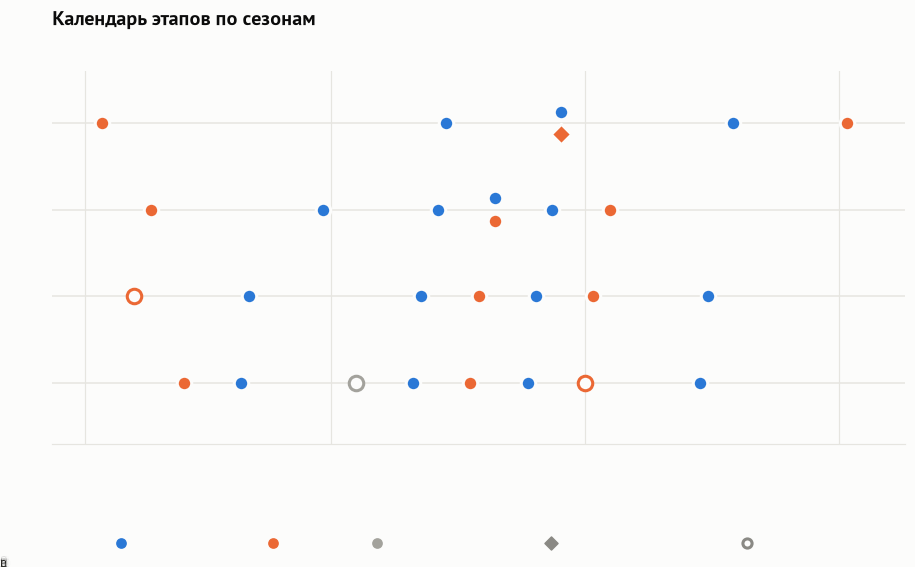

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.4))
years = [2023, 2024, 2025, 2026]
for i, y in enumerate(years):
    g = venues[venues.year == y].sort_values("race_date")
    yy = len(years) - 1 - i
    ax.axhline(yy, color="#e6e5e0", lw=1, zorder=0)
    doy = g.race_date.dt.dayofyear
    clash = doy.duplicated(keep=False)          # два этапа в один день — разводим по вертикали
    for j, (d, name, reg, dq, c) in enumerate(zip(doy, g.event_name, g.macro_region, g.date_quality, clash)):
        color = REGION_COLOR.get(reg, GRAY)
        dy = (0.13 if reg == "Северо-Запад" else -0.13) if c else 0
        rated = y not in in_rating or name in in_rating[y]          # 2023: рейтинга ещё не было
        ax.scatter(d, yy + dy, s=90, color=color if rated else SURFACE, edgecolor=color if not rated else SURFACE,
                   linewidth=2, zorder=3, marker="D" if dq == "approx_late_july" else "o")
        short = name.replace(" Gravel Weekend", "").replace("Спортмарафон Фест", "Спортмарафон").replace("Gravel Instinct", "G. Instinct")
        up = (dy > 0) if c else (j % 2 == 0)
        ax.annotate(short, (float(d), yy + dy), xytext=(0, 9 if up else -16), textcoords="offset points",
                    ha="center", fontsize=8.5, color=TEXT_2)
ax.set_yticks(range(len(years)), years[::-1])
months = {"июнь": 152, "июль": 182, "август": 213, "сентябрь": 244}
ax.set_xticks(list(months.values()), list(months.keys()))
ax.set_xlim(148, 252); ax.set_ylim(-0.7, len(years) - 0.4)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.scatter([], [], color=BLUE, label="Северо-Запад"); ax.scatter([], [], color=ORANGE, label="Центр")
ax.scatter([], [], color=GRAY, label="место не найдено")
ax.scatter([], [], color=TEXT_3, marker="D", label="дата приблизительна")
ax.scatter([], [], color=SURFACE, edgecolor=TEXT_3, linewidth=2, label="вне рейтинга")
ax.legend(loc="lower center", ncols=5, fontsize=9, bbox_to_anchor=(0.5, -0.32))
ax.set_title("Календарь этапов по сезонам")
viz.subtitle(ax, "С 2025 года этапы идут каждую неделю, чередуя регионы. В 2024-м SHULZ и Gravel Instinct совпали по дате")
viz.save(fig, "02_calendar"); plt.show()

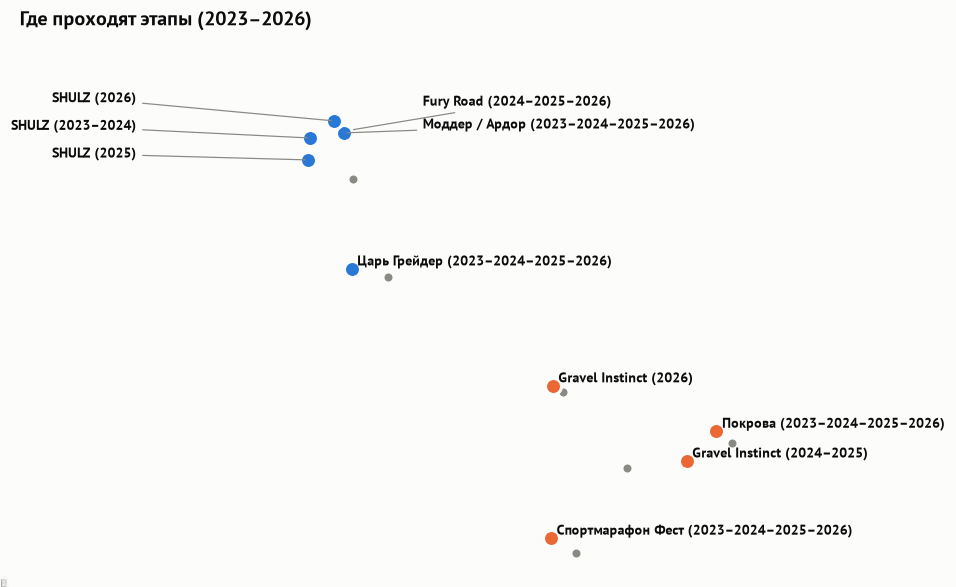

In [8]:
cities = {"Москва": (55.756, 37.617), "Санкт-Петербург": (59.934, 30.335), "Великий Новгород": (58.522, 31.276),
          "Владимир": (56.129, 40.407), "Тверь": (56.859, 35.918), "Калуга": (54.529, 36.275)}
pts = (venues.dropna(subset=["lat"]).groupby(["series_key", "event_name", "lat", "lon", "macro_region"])["year"]
       .agg(lambda s: "–".join(map(str, sorted(set(s))))).reset_index())
fig, ax = plt.subplots(figsize=(9.5, 7.4))
for name, (la, lo) in cities.items():
    ax.scatter(lo, la, s=18, color=TEXT_3, zorder=2)
    ax.text(lo + 0.12, la - 0.05, name, fontsize=8.5, color=TEXT_3)
# на Северо-Западе площадки в десятках км друг от друга — подписи выносим в сторону с выносками
callouts = {("Fury Road", 60.6312): (32.2, 61.05), ("Моддер / Ардор", 60.6067): (32.2, 60.72),
            ("SHULZ Gravel Weekend", 60.78): (24.6, 61.1), ("SHULZ Gravel Weekend", 60.5329): (24.6, 60.7),
            ("SHULZ Gravel Weekend", 60.216): (24.6, 60.3)}
for _, r in pts.iterrows():
    ax.scatter(r.lon, r.lat, s=110, color=REGION_COLOR[r.macro_region], edgecolor=SURFACE, linewidth=2, zorder=3)
    label = f"{r.event_name.replace(' Gravel Weekend', '')} ({r.year})"
    key = (r.event_name, round(r.lat, 4))
    if key in callouts:
        tx, ty = callouts[key]
        ax.annotate(label, (r.lon, r.lat), xytext=(tx, ty), textcoords="data", fontsize=9, color=TEXT, weight="bold",
                    ha="left" if tx > r.lon else "right", va="center",
                    arrowprops=dict(arrowstyle="-", color=TEXT_3, lw=0.8))
    else:
        ax.text(r.lon + 0.15, r.lat + 0.05, label, fontsize=9, color=TEXT, weight="bold")
ax.set_aspect(1 / np.cos(np.radians(57)))
ax.set_xlim(21.5, 43); ax.set_ylim(54.2, 61.5)
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.spines["bottom"].set_visible(False)
ax.set_title("Где проходят этапы (2023–2026)")
viz.subtitle(ax, "Два кластера в ~600 км друг от друга. Fury Road и Ардор — в 3 км друг от друга")
viz.save(fig, "03_map"); plt.show()

**Выводы:**
- Серия — это **два региональных кластера**. **Северо-Запад**: Царь Грейдер (Новгородская обл.), SHULZ, Моддер/Ардор и Fury Road (Карельский перешеек).
  **Центр**: Спортмарафон Фест («Никола-Ленивец», Калужская обл.), Gravel Instinct (2024–2025 — у Покрова, 2026 — Тверская обл.), Покрова (север Владимирской обл.).
- **Моддер и Ардор — одна и та же гонка.** В 2023–2024 годах гравийная гонка на MODDER CX CAMP у станции Петяярви (организаторы — Maskakult и веломастерская MODDER),
  с 2025-го — ARDOR GRAVEL RACE на том же месте в последние выходные июля. В 2026 году на сайте серии этап называется «Моддер и Ардор».
- **Fury Road и Ардор — фактически одна площадка** (около 3 км между кемпами).
- **Календарь уплотнился.** В 2025–2026 годах с середины июня до середины августа этапы идут каждую неделю, и регионы чередуются:
  Северо-Запад → Центр → Северо-Запад… В 2024 году SHULZ и Gravel Instinct прошли в один день (20 июля), а Fury Road стоял за неделю до SHULZ;
  с 2025-го Fury Road перенесли на середину августа.

## 3а. Регионы: два разных продукта под одним рейтингом

Делю гонщиков по тому, где они ездили в сезоне: только Северо-Запад, только Центр или оба региона.
Сначала — как устроен общий рейтинг. По [правилам серии](https://gravelseries.ru/rating/2026) место считается по сумме лучших 4 гонок,
полный зачёт — минимум 4 гонки из 6 рейтинговых. В 2026 году рейтинговые этапы — Царь Грейдер, SHULZ, Ардор, Fury Road (**4 на Северо-Западе**)
и Спортмарафон, Gravel Instinct (**2 в Центре**); Покрова и Redline в рейтинг не входят. В 2025-м — те же 4 на Северо-Западе и Gravel Instinct с Покровой в Центре.

In [9]:
# Три группы гонщиков по тому, где они ездили в сезоне: только Северо-Запад, только Центр, оба региона.
# Полный зачёт — по рейтингу сайта (4+ гонки с очками), сопоставлен с гонщиками через тот же ключ имени.
starts = q(
    "SELECT r.year, r.rider_id, e.event_name, v.macro_region "
    "FROM fct_result r JOIN dim_event e ON e.event_id = r.event_id JOIN dim_venue v ON v.event_id = r.event_id "
    "WHERE r.status <> 'dns' AND r.year >= 2023 AND v.macro_region IS NOT NULL"
).drop_duplicates()
per = (starts.groupby(["year", "rider_id", "macro_region"])["event_name"].nunique()
       .unstack(fill_value=0).rename(columns={"Северо-Запад": "nw", "Центр": "c"}).reset_index())
per["group"] = np.select([per.c == 0, per.nw == 0], ["только Северо-Запад", "только Центр"], "оба региона")

ranking26 = json.loads((raw / "rankings_2026.json").read_text())["entries"]
full_keys = {name_keys(e["displayName"])[0] for e in ranking26 if sum(v > 0 for v in e["breakdown"].values()) >= 4}
keys = q("SELECT rider_id, name_key FROM dim_rider")
p26 = per[per.year == 2026].merge(keys, on="rider_id")
p26["full"] = p26.name_key.isin(full_keys)
print(f"В полном зачёте 2026 по рейтингу сайта: {len(full_keys)}, сопоставлено: {p26.full.sum()}")

groups = ["только Северо-Запад", "оба региона", "только Центр"]
audience = per.pivot_table(index="year", columns="group", values="rider_id", aggfunc="count")[groups]
display(audience)
compare = pd.DataFrame({
    "гонщиков": p26.groupby("group").size(),
    "в полном зачёте": p26.groupby("group")["full"].sum(),
}).loc[groups]
compare["доля в зачёте"] = (compare["в полном зачёте"] / compare["гонщиков"]).round(3)
regional = pd.Series({"Север: 2+ этапа под Петербургом / Новгородом": int((p26.nw >= 2).sum()),
                      "Центр: 2+ этапа в Центре": int((p26.c >= 2).sum())}, name="гонщиков")
display(compare)
regional

В полном зачёте 2026 по рейтингу сайта: 77, сопоставлено: 77


group,только Северо-Запад,оба региона,только Центр
year,,,
2023,196,16,256
2024,339,42,262
2025,709,147,459
2026,920,225,648


,гонщиков,в полном зачёте,доля в зачёте
group,,,
только Северо-Запад,920,29,0.032
оба региона,225,48,0.213
только Центр,648,0,0.000


Север: 2+ этапа под Петербургом / Новгородом    356
Центр: 2+ этапа в Центре                        143
Name: гонщиков, dtype: int64

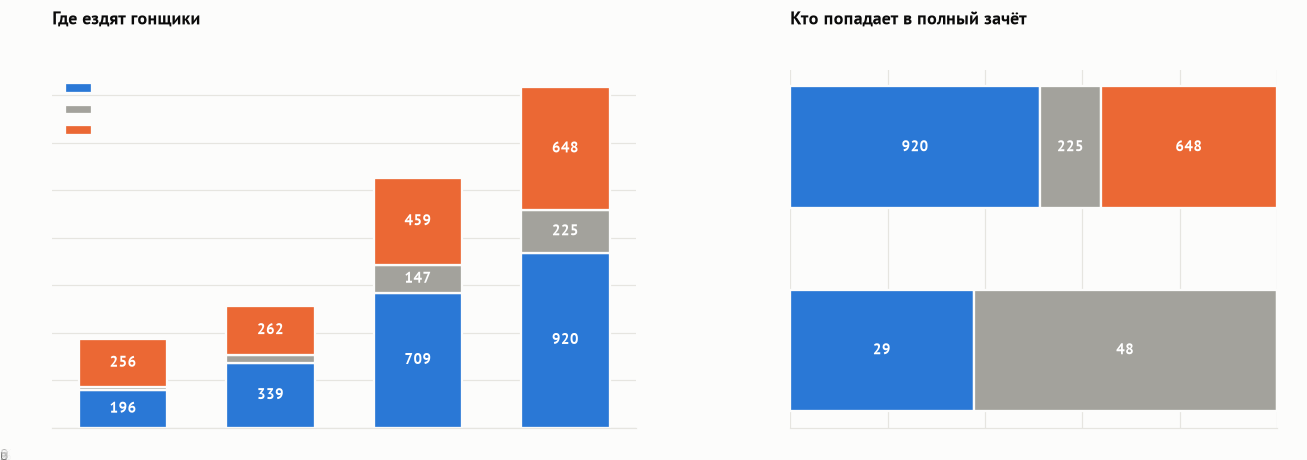

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), gridspec_kw={"width_ratios": [1.2, 1]})
colors = {"только Северо-Запад": BLUE, "оба региона": GRAY, "только Центр": ORANGE}
ax = axes[0]
bottom = np.zeros(len(audience))
for g in groups:
    ax.bar(audience.index, audience[g], bottom=bottom, color=colors[g], width=0.6, label=g, edgecolor=SURFACE, linewidth=1.5)
    for x, v, b in zip(audience.index, audience[g], bottom):
        if v > 60:
            ax.text(x, b + v / 2, f"{v}", ha="center", va="center", color="white", fontsize=9.5, weight="bold")
    bottom += audience[g].values
ax.set_xticks(audience.index); ax.legend(loc="upper left", fontsize=9)
ax.set_title("Где ездят гонщики", fontsize=12)
viz.subtitle(ax, "Большинство катается только в своём регионе")

ax = axes[1]
for i, col in enumerate(["гонщиков", "в полном зачёте"]):
    tot = compare[col].sum(); left = 0
    for g in groups:
        v = compare.loc[g, col]; share = v / tot
        ax.barh(i, share, left=left, color=colors[g], height=0.6, edgecolor=SURFACE, linewidth=1.5)
        if v > 0:
            ax.text(left + share / 2, i, f"{v}", ha="center", va="center", color="white", fontsize=10, weight="bold")
        left += share
ax.set_yticks([0, 1], ["все гонщики 2026", "полный зачёт 2026"]); ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0)); ax.set_xlim(0, 1)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_title("Кто попадает в полный зачёт", fontsize=12)
viz.subtitle(ax, "Из 648 гонщиков «только Центр» — никто")
fig.tight_layout()
viz.save(fig, "03a_regions"); plt.show()

**Выводы:**
- Большинство гонщиков катается **только в своём регионе**: в 2026 году 920 — только на Северо-Западе, 648 — только в Центре, в оба региона ездили 225 (12%).
- **В полном зачёте 77 человек.** 48 из них ездили в оба региона, 29 — только на Северо-Западе, **из тех, кто катается только в Центре, — никого**.
  По правилам это и невозможно: в Центре 2 рейтинговых этапа, а для зачёта нужно 4. Гонщику с Северо-Запада для зачёта ехать никуда не нужно,
  гонщику из Центра — минимум дважды под Петербург.
- Полный зачёт получается «клубом путешественников»: 62% его участников ездят в оба региона, хотя таких среди всех гонщиков 12%.

💡 **Предложение: региональные зачёты.**
- **«Север»** — Царь Грейдер, SHULZ, Ардор, Fury Road. **«Центр»** — Спортмарафон, Gravel Instinct и Покрова (вернув её в рейтинг, как в 2025 году).
- Порог — **2 этапа своего региона**. Он совпадает с aha-моментом из раздела 6: вторая гонка в первом сезоне — главный предиктор возврата.
- По данным 2026 года в региональной борьбе оказались бы **143 гонщика в «Центре»** и **356 в «Севере»** — против 77 в нынешнем полном зачёте.
  Общий зачёт по 4 гонкам остаётся «абсолютом» для тех, кто ездит по всей стране.
- Эффект на удержание можно проверить, вводя зачёт поэтапно по регионам.

## 4. Рост 2023–2026: аудитория ×3,9, частота стартов ×1,3

In [11]:
cross = q('''
SELECT r.year,
       COUNT(DISTINCT r.rider_id) AS riders,
       COUNT(DISTINCT r.rider_id) FILTER (WHERE n_reg >= 2) AS cross_region
FROM fct_result r
JOIN (SELECT r.year, r.rider_id, COUNT(DISTINCT v.macro_region) AS n_reg
      FROM fct_result r JOIN dim_venue v ON v.event_id = r.event_id
      WHERE r.status <> 'dns' GROUP BY ALL) x ON x.year = r.year AND x.rider_id = r.rider_id
WHERE r.status <> 'dns' AND r.year >= 2023
GROUP BY 1 ORDER BY 1
''')
growth = season[season.year >= FROM_YEAR][["year", "n_events", "riders", "starts", "starts_per_rider", "new_riders",
                                           "retained_from_prev", "resurrected", "female_share", "multi_event_share"]]
growth = growth.merge(cross[["year", "cross_region"]], on="year")
growth["cross_region_share"] = (growth.cross_region / growth.riders).round(3)
growth

,year,n_events,riders,starts,starts_per_rider,new_riders,retained_from_prev,resurrected,female_share,multi_event_share,cross_region,cross_region_share
0,2023,6,468,538.0,1.15,336.0,67.0,65.0,0.184,0.124,16,0.034
1,2024,7,643,844.0,1.31,386.0,192.0,65.0,0.168,0.219,42,0.065
2,2025,7,1315,1927.0,1.47,854.0,357.0,104.0,0.186,0.278,147,0.112
3,2026,8,1814,2786.0,1.54,1010.0,691.0,113.0,0.193,0.314,225,0.124


**Выводы:**
- Уникальных участников: **468 → 1 814** (×3,9), стартов: 538 → 2 786. Число стартов на гонщика выросло с 1,15 до **1,54**.
- В 2026 году **691** участник (38%) вернулся с прошлого сезона; в 2023-м — 67 (14%). Рост всё меньше зависит от одних новичков.
- Доля проехавших 2+ этапа: 12% → **31%**. Доля ездящих **в оба региона**: 3% → **12–13%**. Самый заметный скачок пришёлся на 2025 год,
  год официального запуска серии с общим рейтингом (6,5% → 11,2%). Рост начался ещё до запуска, поэтому эффект самой серии отделить нельзя.
- Доля женщин стабильна: 17–19%.

## 5. Удержание: 35% → 51% → 45%

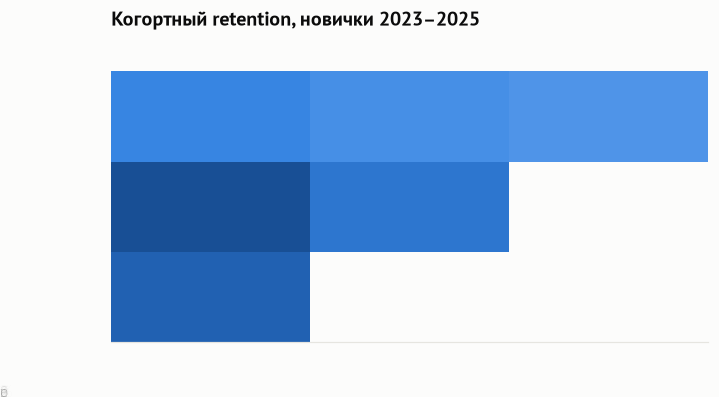

In [12]:
cohort = q(f"SELECT cohort, season_n, retention, riders FROM mart_cohort WHERE cohort BETWEEN {FROM_YEAR} AND 2025")
heat = cohort.pivot(index="cohort", columns="season_n", values="retention").drop(columns=0)
sizes = cohort[cohort.season_n == 0].set_index("cohort")["riders"]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.imshow(heat.values, cmap=viz.BLUES, vmin=0, vmax=0.6, aspect="auto")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=11, color="white" if v > 0.33 else TEXT)
ax.set_xticks(range(heat.shape[1]), [f"+{c}" for c in heat.columns])
ax.set_yticks(range(heat.shape[0]), [f"{c}  (n={sizes[c]})" for c in heat.index])
ax.set_xlabel("сезонов после первого старта"); ax.grid(False)
ax.set_title("Когортный retention, новички 2023–2025")
viz.subtitle(ax, "Новичок = первый старт в архиве с 2018 года; когорта = год первого старта")
viz.save(fig, "04_cohorts"); plt.show()

**Выводы:**
- Retention на следующий сезон: **35%** (когорта 2023) → **51%** (2024) → **45%** (2025). Удержание выросло, хотя когорты стали в 2,5 раза больше.
- Просадку 2025 года (−6 п.п.) объясняет размер когорты: 854 новичка против 386, среди них больше «случайных» людей.
  Это не тревожный сигнал, но метрику стоит мониторить.
- Кто остался на второй сезон, тот держится: у когорты 2023 года 35% → 32% → 31%.

## 6. Aha-момент: вторая гонка в первом сезоне

Новички когорт 2023–2025 (первый старт в архиве — в этом году). Вернулся ли человек в следующем сезоне и что отличало его первый сезон?

In [13]:
newbies = q('''
WITH act AS (
    SELECT r.*, d.is_long FROM fct_result r JOIN dim_race d ON d.race_id = r.race_id
    WHERE r.status <> 'dns'
),
first AS (SELECT rider_id, MIN(year) AS fy FROM act GROUP BY 1),
fs AS (
    SELECT a.rider_id, f.fy,
           ANY_VALUE(a.gender)              AS gender,
           COUNT(*)                         AS starts,
           BOOL_OR(a.is_long)               AS any_long,
           MEDIAN(a.pct_rank)               AS med_pct,
           ARG_MIN(a.event_id, a.result_id) AS first_event,
           MODE(v.macro_region)             AS macro_region
    FROM act a JOIN first f ON f.rider_id = a.rider_id AND a.year = f.fy
    LEFT JOIN dim_venue v ON v.event_id = a.event_id
    GROUP BY 1, 2
),
ret AS (SELECT DISTINCT rider_id, year FROM act)
SELECT fs.*, (r.rider_id IS NOT NULL)::INT AS returned
FROM fs LEFT JOIN ret r ON r.rider_id = fs.rider_id AND r.year = fs.fy + 1
WHERE fy BETWEEN 2023 AND 2025
''')
newbies = newbies.merge(q("SELECT event_id, series_key, event_name FROM dim_event"), left_on="first_event", right_on="event_id")
newbies["starts_cat"] = newbies["starts"].clip(upper=3).map({1: "1", 2: "2", 3: "3+"})
newbies["pct_q"] = pd.cut(newbies["med_pct"], [-0.01, 0.25, 0.5, 0.75, 1.0],
                          labels=["топ-25%", "25–50%", "50–75%", "хвост"])
print(f"Новичков: {len(newbies)}, вернулись на следующий сезон: {newbies.returned.mean():.1%}")

Новичков: 1576, вернулись на следующий сезон: 44.6%


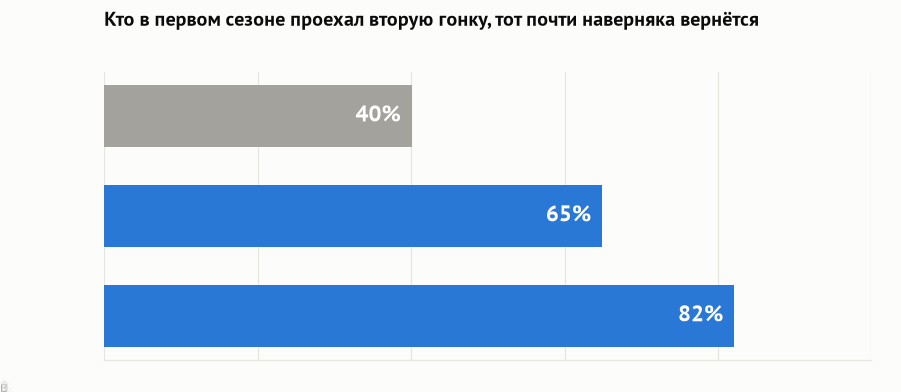

вернулись  новичков
Первая дистанция      только короткая       37%       693
                      длинная               51%       883
Место среди финишёров топ-25%               48%       267
                      25–50%                48%       377
                      50–75%                48%       432
                      хвост                 38%       490
Регион первого сезона Северо-Запад          45%       822
                      Центр                 44%       754
Пол                   женщины               39%       312
                      мужчины               46%      1264

In [14]:
def rate(col, order=None):
    g = newbies.groupby(col, observed=True)["returned"].agg(["mean", "size"])
    return g.loc[order] if order else g

# главный вывод — одним графиком
main = rate("starts_cat", ["1", "2", "3+"]).rename(index={"1": "1 гонка", "2": "2 гонки", "3+": "3 и больше"})
fig, ax = plt.subplots(figsize=(9, 3.4))
colors = [GRAY, BLUE, BLUE]
ax.barh(main.index[::-1], main["mean"][::-1], color=colors[::-1], height=0.62)
for i, (v, n) in enumerate(zip(main["mean"][::-1], main["size"][::-1])):
    ax.text(v - 0.015, i, f"{v:.0%}", va="center", ha="right", color="white", fontsize=15, weight="bold")
    ax.text(v + 0.015, i, f"{n:,} чел.".replace(",", " "), va="center", color=TEXT_3, fontsize=9)
ax.set_xlim(0, 1); ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.tick_params(axis="y", labelsize=12)
ax.set_title("Кто в первом сезоне проехал вторую гонку, тот почти наверняка вернётся")
viz.subtitle(ax, "Доля новичков 2023–2025, вернувшихся на следующий сезон, по числу гонок в первом сезоне")
viz.save(fig, "05_aha_moment"); plt.show()

# остальные факторы — таблицей, без отдельных графиков
other = pd.concat({
    "Первая дистанция": rate("any_long").rename(index={False: "только короткая", True: "длинная"}),
    "Место среди финишёров": rate("pct_q"),
    "Регион первого сезона": rate("macro_region"),
    "Пол": rate("gender").rename(index={"F": "женщины", "M": "мужчины"}),
}).rename(columns={"mean": "вернулись", "size": "новичков"})
other["вернулись"] = other["вернулись"].map("{:.0%}".format)
other

Вторая гонка в первом сезоне поднимает возврат с 40% до 65%, третья и далее — до 82%. Остальные факторы различаются куда слабее (таблица выше), а регион не влияет совсем (45% против 44%).
Но это корреляция. Проверяю эффекты вместе в логистической регрессии, в двух спецификациях:
1. фиксированный эффект года — убирает общий тренд роста серии;
2. плюс фиксированный эффект первого этапа — альтернативное объяснение «дело не в числе стартов, а в том, на какой этап человек попал».

In [15]:
newbies["multi_start"] = (newbies.starts >= 2).astype(int)
newbies["female"] = (newbies.gender == "F").astype(int)
newbies["bottom_q"] = (newbies.med_pct > 0.75).astype(int)
newbies["long"] = newbies.any_long.astype(int)
d = newbies.dropna(subset=["med_pct"])
specs = {
    "1: год": "returned ~ multi_start + long + bottom_q + female + C(fy)",
    "2: год + первый этап": "returned ~ multi_start + long + bottom_q + female + C(fy) + C(series_key)",
}
rows = []
for name, f in specs.items():
    m = smf.logit(f, data=d).fit(disp=0)
    ci = np.exp(m.conf_int())
    for v in ["multi_start", "long", "bottom_q", "female"]:
        rows.append({"модель": name, "фактор": v, "OR": np.exp(m.params[v]),
                     "ДИ 95%": f"{ci.loc[v, 0]:.2f}–{ci.loc[v, 1]:.2f}", "p": m.pvalues[v]})
pd.DataFrame(rows).pivot(index="фактор", columns="модель", values=["OR", "ДИ 95%", "p"]).round(3)

OR                          ДИ 95%                       \
модель         1: год 2: год + первый этап     1: год 2: год + первый этап   
фактор                                                                       
bottom_q     0.681499             0.666898  0.54–0.85            0.53–0.84   
female       0.842806             0.829108  0.65–1.10            0.63–1.08   
long         1.498518             1.271396  1.20–1.87            0.94–1.72   
multi_start  2.687155              2.92204  1.98–3.64            2.12–4.03   

                    p                       
модель         1: год 2: год + первый этап  
фактор                                      
bottom_q     0.000861             0.000483  
female       0.207824             0.170646  
long         0.000309             0.118723  
multi_start       0.0                  0.0

**Выводы:**
- **Вторая гонка в первом сезоне — главный и устойчивый предиктор возврата:** OR = 2,69 [1,98–3,64]; с поправкой на первый этап — **2,92** [2,12–4,03].
- **Финиш в последней четверти** снижает шансы на возврат примерно на треть (OR = 0,67–0,68) в обеих моделях. Негативный первый опыт стоит отрабатывать отдельно.
- **Длинная дистанция** связана с возвратом (51% против 37%, OR = 1,50), но с поправкой на этап эффект незначим (p = 0,12):
  его в основном объясняет то, на какие этапы приходят новички.
- **Пол** незначим в обеих моделях. Женщины чаще едут короткую дистанцию: 39% стартов на длинной против 55% у мужчин.

⚠️ Одно альтернативное объяснение исключить нельзя: в первый же сезон две гонки едут просто более мотивированные люди. Поэтому — эксперимент.

## 6а. Как проверить причинность: дизайн A/B-теста

**Гипотеза:** промокод на следующий этап для финишёров первого старта увеличит долю новичков со вторым стартом в том же сезоне,
а через это — возврат на следующий сезон. Календарь это позволяет: в 2025–2026 годах этапы идут каждую неделю,
и у новичка почти всегда есть следующий этап через 2–3 недели в своём регионе.

| | |
|---|---|
| Единица рандомизации | новичок-финишёр (первый старт в серии) |
| Группы | A — обычное письмо после гонки; B — письмо + промокод на следующий этап своего региона |
| Основная метрика | доля сделавших 2+ стартов в сезоне |
| Вторичная метрика | возврат в следующем сезоне (результат через год) |
| Защитная метрика | выручка с новичка (скидка не должна «съесть» доход) |
| Стратификация | по региону и первому этапу |

In [16]:
p0 = newbies.loc[newbies.fy == 2025, "multi_start"].mean()
power = NormalIndPower()
plan = pd.DataFrame([
    {"прирост, п.п.": int(dd * 100), "целевой уровень": p0 + dd,
     "нужно на группу": int(np.ceil(power.solve_power(proportion_effectsize(p0 + dd, p0), alpha=0.05, power=0.8)))}
    for dd in (0.04, 0.05, 0.06, 0.08, 0.10)
])
n_season = int((newbies.fy == 2025).sum())
mde = next(dd / 100 for dd in range(1, 30)
           if power.solve_power(proportion_effectsize(p0 + dd / 100, p0), alpha=0.05, power=0.8) <= n_season / 2)
print(f"Базовый уровень p0 = {p0:.1%}; новичков за сезон ~{n_season}")
print(f"MDE при 50/50 за один сезон: +{mde:.0%} (п.п.)")
plan.round(3)

Базовый уровень p0 = 19.1%; новичков за сезон ~854
MDE при 50/50 за один сезон: +9% (п.п.)


,"прирост, п.п.",целевой уровень,нужно на группу
0,4,0.231,1630
1,5,0.241,1060
2,6,0.251,748
3,8,0.271,433
4,10,0.291,285


**Вывод:** при ~850 новичках за сезон и сплите 50/50 тест заметит прирост от ~9 п.п. (с 19% до 28%) с мощностью 80%.
Для эффекта в +5 п.п. нужно ~2 120 новичков, то есть два сезона. Тест дешёвый: стоимость — только скидка для группы B.

## 7. Точки входа: после каких этапов новички возвращаются

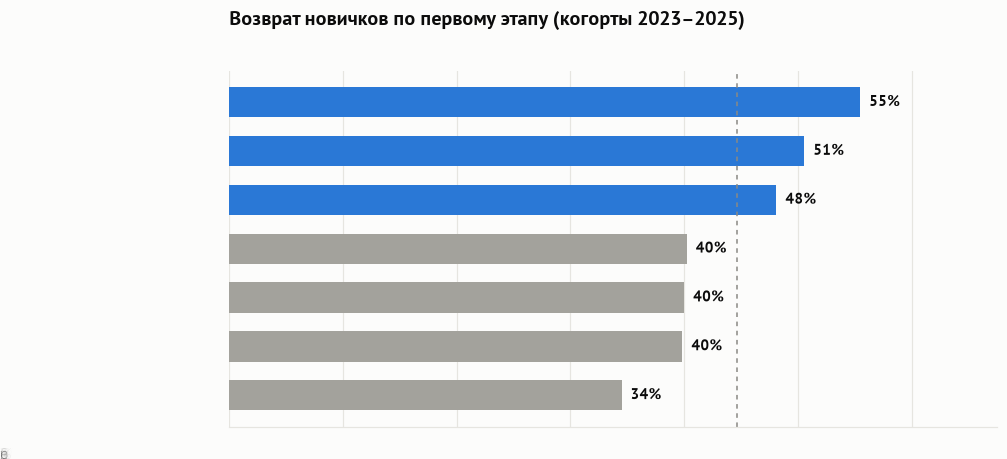

,mean,size
event_name,,
Спортмарафон Фест,0.345,345
SHULZ Gravel Weekend,0.398,261
Gravel Instinct,0.400,105
Моддер / Ардор,0.402,87
Fury Road,0.481,212
Царь Грейдер,0.506,265
Покрова (вне рейтинга с 2026),0.555,301


In [17]:
e = (newbies.groupby("event_name")["returned"].agg(["mean", "size"])
     .query("size >= 40").sort_values("mean"))
e = e.rename(index={"Покрова": "Покрова (вне рейтинга с 2026)"})
avg = newbies.returned.mean()
fig, ax = plt.subplots(figsize=(9, 4.2))
colors = [BLUE if v >= avg else GRAY for v in e["mean"]]
ax.barh(e.index, e["mean"], color=colors, height=0.62)
ax.axvline(avg, color=TEXT_3, lw=1, ls=(0, (3, 3)))
for i, (v, n) in enumerate(zip(e["mean"], e["size"])):
    ax.text(v + 0.008, i, f"{v:.0%}  ", va="center", weight="bold", fontsize=10)
    ax.text(v + 0.055, i, f"n={n}", va="center", color=TEXT_3, fontsize=8.5)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlim(0, e["mean"].max() + 0.12)
ax.set_title("Возврат новичков по первому этапу (когорты 2023–2025)")
viz.subtitle(ax, f"Доля вернувшихся на следующий сезон; пунктир — среднее {avg:.0%}")
viz.save(fig, "06_entry_points"); plt.show()
e.round(3)

**Вывод:** разброс между этапами — 21 п.п. Лучшие «точки входа» — **Покрова (55%)** и **Царь Грейдер (51%)**, хуже всех — **Спортмарафон Фест (34%)**.
Покрова в 2026 году выведена из рейтинга серии, хотя лучше всех приводит новичков, которые потом возвращаются. Это аргумент вернуть её в рейтинг —
заодно в Центре станет три рейтинговых этапа вместо двух.
Регион здесь ни при чём: лидеры есть в обоих регионах. Спортмарафон — мультиспортивный фестиваль массового бренда с короткими дистанциями 40/65 км,
он привлекает разовых участников, а не гревел-аудиторию. Это гипотеза для проверки, а не установленная причина.

## 8. Экосистема: общую аудиторию этапов определяет расстояние

In [18]:
pairs = q("SELECT * FROM mart_event_pairs WHERE km IS NOT NULL")
pairs["same_region"] = (pairs.region_a == pairs.region_b).astype(int)
pairs["log_km"] = np.log10(pairs.km + 1)
print(f"Пар этапов одного сезона с известными координатами: {len(pairs)}")
models = {
    "расстояние": "share_of_smaller ~ log_km + C(year)",
    "расстояние + интервал": "share_of_smaller ~ log_km + gap_days + C(year)",
}
out = []
for name, f in models.items():
    m = smf.ols(f, data=pairs).fit(cov_type="HC1")
    out.append({"модель": name, "R²": m.rsquared, "коэф. log10(км)": m.params["log_km"],
                "коэф. интервал, дни": m.params.get("gap_days", np.nan), "p интервала": m.pvalues.get("gap_days", np.nan)})
print(pairs.groupby("same_region")["share_of_smaller"].median().rename({0: "разные регионы", 1: "один регион"}).round(3))
pd.DataFrame(out).round(4)

Пар этапов одного сезона с известными координатами: 69
same_region
разные регионы    0.101
один регион       0.332
Name: share_of_smaller, dtype: float64


,модель,R²,коэф. log10(км),"коэф. интервал, дни",p интервала
0,расстояние,0.7000,-0.2091,NaN,NaN
1,расстояние + интервал,0.7088,-0.2060,-0.0008,0.0825


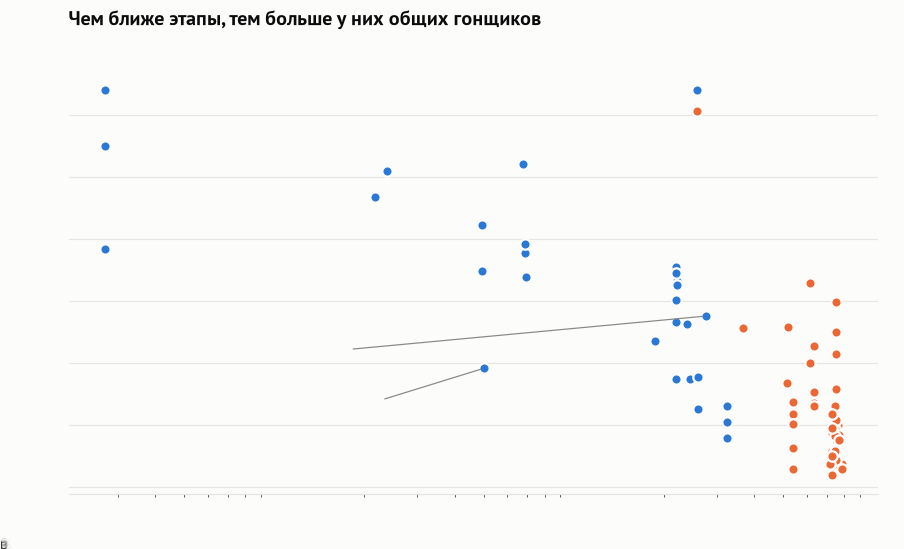

In [19]:
fig, ax = plt.subplots(figsize=(9.5, 5))
for same, color, label in [(1, BLUE, "этапы одного региона"), (0, ORANGE, "этапы разных регионов")]:
    g = pairs[pairs.same_region == same]
    ax.scatter(g.km, g.share_of_smaller, s=46, color=color, edgecolor=SURFACE, linewidth=1.5, label=label, zorder=3)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", " ")))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
notes = [("Fury Road", "Моддер / Ардор", 2026, "Fury Road – Ардор, 2026", (8, 6)),
         ("Fury Road", "SHULZ Gravel Weekend", 2024, "Fury Road – SHULZ, 2024\n(через неделю)", (-150, -40)),
         ("Fury Road", "SHULZ Gravel Weekend", 2026, "Fury Road – SHULZ, 2026", (8, 6)),
         ("Gravel Instinct", "Покрова", 2025, "G. Instinct – Покрова, 2025", (8, 6)),
         ("Gravel Instinct", "Покрова", 2026, "G. Instinct – Покрова, 2026\n(гонка переехала в Тверскую обл.)", (-360, -35))]
for a, b, y, text, off in notes:
    r = pairs[(pairs.year == y) & (pairs.event_a.isin([a, b])) & (pairs.event_b.isin([a, b]))]
    if len(r):
        r = r.iloc[0]
        ax.annotate(text, (r.km, r.share_of_smaller), xytext=off, textcoords="offset points", fontsize=8.5, color=TEXT_2,
                    arrowprops=dict(arrowstyle="-", color=TEXT_3, lw=0.8) if off != (8, 6) else None)
ax.set_xlabel("расстояние между площадками, км (лог. шкала)")
ax.set_ylabel("общих участников, % аудитории меньшего этапа")
ax.legend(loc="upper right", fontsize=9)
ax.set_title("Чем ближе этапы, тем больше у них общих гонщиков")
viz.subtitle(ax, "Пары этапов одного сезона, 2023–2026. Расстояние объясняет ~70% разброса")
viz.save(fig, "07_distance_overlap"); plt.show()

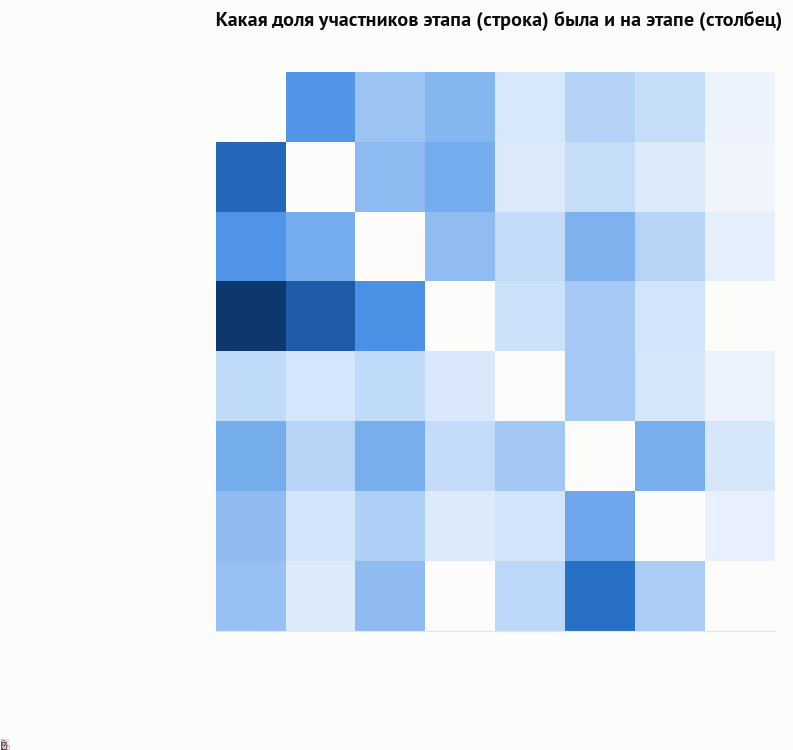

In [20]:
ov = q("SELECT event_a, event_b, share_of_a FROM mart_event_overlap WHERE year = 2026")
sizes26 = q('''SELECT e.event_name, COUNT(DISTINCT r.rider_id) n FROM fct_result r
               JOIN dim_event e ON e.event_id = r.event_id WHERE r.year = 2026 AND r.status <> 'dns' GROUP BY 1''')
region = venues[venues.year == 2026].set_index("event_name")["macro_region"]
order = (sizes26.assign(reg=sizes26.event_name.map(region).fillna("я"))
         .sort_values(["reg", "n"], ascending=[True, False])["event_name"].tolist())
mat = ov.pivot(index="event_a", columns="event_b", values="share_of_a").reindex(index=order, columns=order)
fig, ax = plt.subplots(figsize=(8.6, 6.6))
ax.imshow(mat.values, cmap=viz.BLUES, vmin=0, vmax=0.65)
for i in range(len(order)):
    for j in range(len(order)):
        v = mat.values[i, j]
        if i == j:
            ax.text(j, i, "—", ha="center", va="center", color=TEXT_3)
        elif not np.isnan(v):
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=9, color="white" if v > 0.35 else TEXT)
n = sizes26.set_index("event_name")["n"]
ax.set_yticks(range(len(order)), [f"{o}  ({n[o]})" for o in order])
ax.set_xticks(range(len(order)), order, rotation=35, ha="right")
for lbl in ax.get_yticklabels() + ax.get_xticklabels():
    lbl.set_color(REGION_COLOR.get(region.get(lbl.get_text().split("  (")[0]), TEXT_2))
ax.grid(False)
ax.set_title("Какая доля участников этапа (строка) была и на этапе (столбец)")
viz.subtitle(ax, "Сезон 2026. Цвет подписи — регион: синий — Северо-Запад, оранжевый — Центр")
viz.save(fig, "08_overlap_matrix"); plt.show()

**Выводы:**
- **Расстояние объясняет ~70% разброса** общей аудитории пар этапов. Внутри региона у этапов обычно треть общих участников, между регионами — около 10%.
- **Ядро серии — Карельский перешеек.** Ардор и Fury Road в 3 км друг от друга: 64% участников Ардора в 2026 году ехали и Fury Road.
  SHULZ проходит там же — 47–52% общих участников.
- **Интервал между этапами** при учёте расстояния почти ничего не добавляет (p = 0,08), но есть сигнал. В 2024 году Fury Road стоял
  за неделю до SHULZ, и общих участников было 19%. После переноса Fury Road на август — 34% (2025) и 47% (2026). Перенос совпал
  с запуском серии, поэтому эффект календаря отделить нельзя.
- **Второй «естественный эксперимент» — переезд Gravel Instinct.** В 2024–2025 годах он проходил у Покрова, в 70 км от Покровы, и общих участников было 38–39%.
  В 2026-м гонка переехала в Тверскую область (~280 км), и доля упала до 28%.
- Спортмарафон почти изолирован: 8–18% общих участников с остальными этапами Центра.

💡 **Что это значит для календаря.** Подряд один регион, потом другой — плохая идея. Тогда этапы одного региона окажутся через неделю друг от друга,
как в 2024 году (Fury Road → SHULZ → Моддер каждую неделю: 19–42% общих участников против 47–64% в 2026-м, когда интервалы 2–3 недели).
Нынешнее **чередование регионов правильное**: в каждом регионе этап раз в 2–3 недели, а соседние недели закрывает другой регион. По той же причине
перенос Gravel Instinct на неделю после Ардора не нужен: это 1 августа 2026 года — тот же день, что и Покрова, с которой у Gravel Instinct
28% общих участников. Получилось бы совпадение дат внутри Центра. Что стоит закрепить: этапы одного региона — не чаще раза в 2 недели, без совпадений дат (как SHULZ и Gravel Instinct 20 июля 2024 года).
Главная проблема календаря не в порядке, а в том, что **в Центре мало рейтинговых этапов** (раздел 3а).

## 9. Дистанции: короткая — отдельный продукт, а не ступенька

first_season_long
короткая    0.371
длинная     0.505
Name: returned_next, dtype: float64


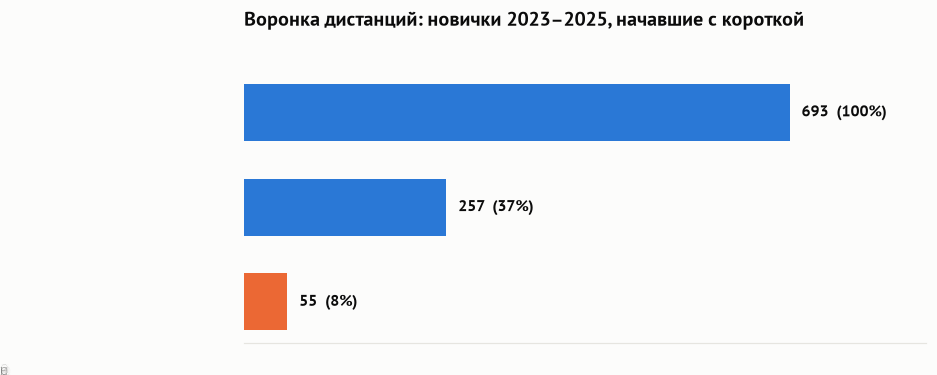

Первый сезон — только короткая    693
Вернулись в следующем сезоне      257
...и проехали длинную              55
dtype: int64

In [21]:
# окно наблюдения одинаковое для всех когорт: первый сезон + следующий
path = q("SELECT * FROM mart_distance_path WHERE first_year BETWEEN 2023 AND 2025")
print(path.groupby("first_season_long")["returned_next"].mean().rename({False: "короткая", True: "длинная"}).round(3))
short = path[~path.first_season_long]
funnel = pd.Series({
    "Первый сезон — только короткая": len(short),
    "Вернулись в следующем сезоне": int(short.returned_next.sum()),
    "...и проехали длинную": int(short.long_next.sum()),
})
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(funnel.index[::-1], funnel.values[::-1], color=[BLUE, BLUE, ORANGE][::-1], height=0.6)
for i, v in enumerate(funnel.values[::-1]):
    ax.text(v + 15, i, f"{v}  ({v / funnel.iloc[0]:.0%})", va="center", weight="bold")
ax.grid(axis="y", visible=False); ax.set_xlim(0, funnel.max() * 1.25)
ax.set_title("Воронка дистанций: новички 2023–2025, начавшие с короткой")
viz.subtitle(ax, "Окно: первый сезон + следующий. Из вернувшихся на длинную выходит лишь каждый пятый")
viz.save(fig, "09_distance_funnel"); plt.show()
funnel

**Вывод:** с короткой дистанции на следующий сезон возвращаются **37%** (с длинной — 51%), и из вернувшихся на длинную выходит только **21%**.
Короткая дистанция — **отдельный продукт со своей аудиторией**. Её удержание нужно растить отдельно, а не рассчитывать, что люди «дорастут» до длинной.

> **Методическая заметка.** Первая версия воронки считала переход за всё время наблюдения и давала 53%. Это завышение:
> у ранних когорт было больше лет на переход. При одинаковом окне (первый сезон + следующий) — 21%.

## 9а. Кто гоняется: женщины и мужчины

In [22]:
gender_dist = q(
    "SELECT CASE WHEN d.is_long THEN 'длинная' ELSE 'короткая' END AS distance, "
    "AVG((r.gender = 'F')::INT) AS female_share, COUNT(*) AS starts "
    "FROM fct_result r JOIN dim_race d ON d.race_id = r.race_id "
    "WHERE r.status <> 'dns' AND r.year >= 2023 GROUP BY 1 ORDER BY 1 DESC")
gender_ret = (newbies.assign(distance=np.where(newbies.any_long, "длинная", "только короткая"),
                             пол=newbies.gender.map({"F": "женщины", "M": "мужчины"}))
              .groupby(["distance", "пол"])["returned"].agg(["mean", "size"]).round(3))
display(gender_dist)
gender_ret

,distance,female_share,starts
0,короткая,0.225718,2924
1,длинная,0.131820,3171


mean  size
distance        пол                 
длинная         женщины  0.512   125
                мужчины  0.504   758
только короткая женщины  0.310   187
                мужчины  0.393   506

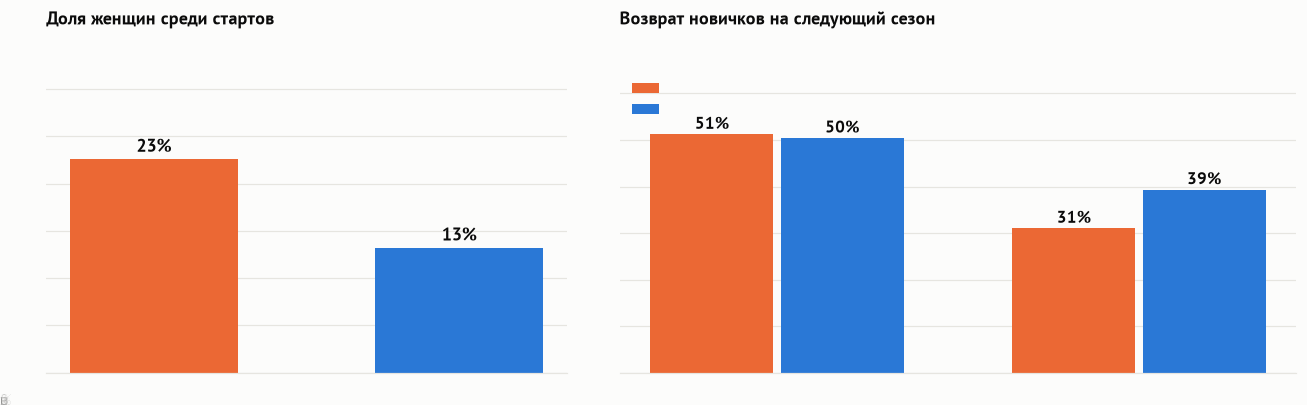

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1, 1.3]})
ax = axes[0]
gd = gender_dist.set_index("distance")["female_share"].reindex(["короткая", "длинная"])
ax.bar(gd.index, gd.values, color=[ORANGE, BLUE], width=0.55)
for i, v in enumerate(gd.values):
    ax.text(i, v + 0.008, f"{v:.0%}", ha="center", weight="bold", fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0)); ax.set_ylim(0, 0.32)
ax.set_title("Доля женщин среди стартов", fontsize=12)
viz.subtitle(ax, "2023–2026, по типу дистанции")

ax = axes[1]
gr = gender_ret["mean"].unstack()
x = np.arange(len(gr.index))
for k, (sex, color) in enumerate([("женщины", ORANGE), ("мужчины", BLUE)]):
    ax.bar(x + (k - 0.5) * 0.36, gr[sex], width=0.34, color=color, label=sex)
    for xi, v in zip(x, gr[sex]):
        ax.text(xi + (k - 0.5) * 0.36, v + 0.012, f"{v:.0%}", ha="center", weight="bold", fontsize=11)
ax.set_xticks(x, gr.index); ax.legend(loc="upper left", fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0)); ax.set_ylim(0, 0.65)
ax.set_title("Возврат новичков на следующий сезон", fontsize=12)
viz.subtitle(ax, "На длинной женщины возвращаются как мужчины, на короткой — реже")
fig.tight_layout()
viz.save(fig, "09a_gender"); plt.show()

**Выводы:**
- Женщин среди участников стабильно **17–19%**. На коротких дистанциях — 23% стартов, на длинных — 13%. Больше всего женщин на Спортмарафоне (25%), меньше всего на Ардоре (10%).
- **На длинной дистанции женщины возвращаются так же, как мужчины** (51% против 50%). Разрыв только **на короткой: 31% против 39%**.
  Точка роста — удержание женщин, пришедших на короткую дистанцию: отдельный зачёт, женские группы, следующая цель после первой гонки.
- В полном зачёте серии 2026 года 9 женщин из 77.
- **Возраст** проанализировать нельзя: в архиве протоколов его нет, в карточках гонщиков на сайте год рождения пустой, у части хронометражей (O-time) столбец
  года рождения есть, но не заполнен. Если организаторы поделятся анкетами регистрации, это следующий шаг.

## 10. Трассы: скорость и сходы (2026)

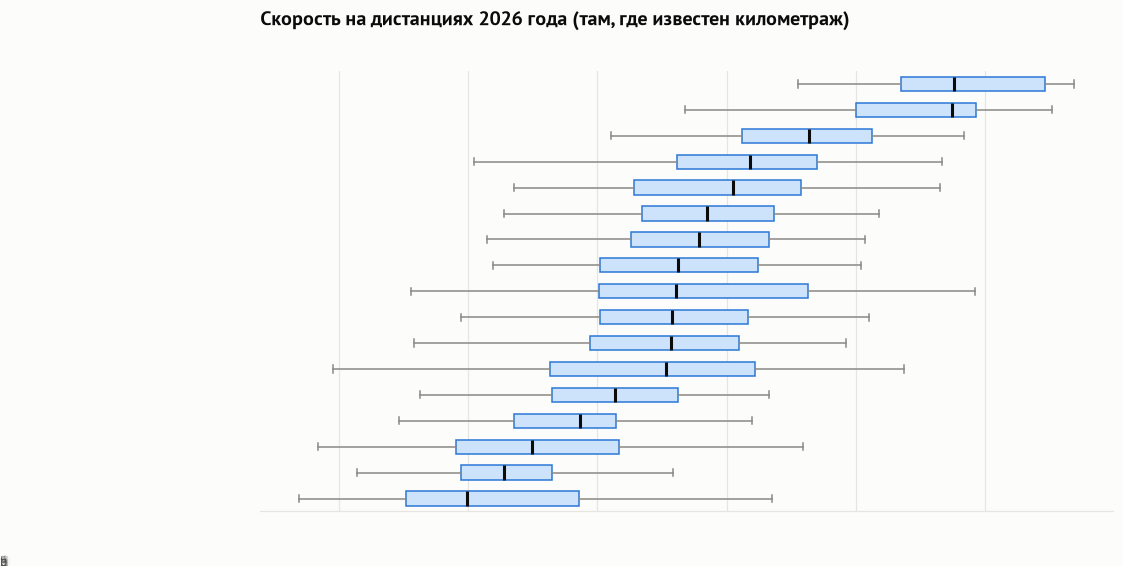

In [24]:
sp = q('''
SELECT e.event_name || ' · ' || d.race_title AS race, d.distance_km, r.speed_kmh
FROM fct_result r JOIN dim_race d ON d.race_id = r.race_id JOIN dim_event e ON e.event_id = r.event_id
WHERE r.year = 2026 AND r.status = 'finished' AND r.speed_kmh IS NOT NULL AND d.bike_class = 'multi'
''')
order = sp.groupby("race")["speed_kmh"].median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 5.2))
data = [sp.loc[sp.race == r, "speed_kmh"] for r in order]
ax.boxplot(data, orientation="horizontal", widths=0.55, patch_artist=True, showfliers=False,
           medianprops=dict(color=TEXT, lw=2), whiskerprops=dict(color=TEXT_3),
           capprops=dict(color=TEXT_3), boxprops=dict(facecolor="#cde2fb", edgecolor=BLUE))
ax.set_yticks(range(1, len(order) + 1), order, fontsize=9)
for i, dd in enumerate(data, 1):
    ax.text(dd.median(), i + 0.38, f"{dd.median():.1f}", ha="center", fontsize=8.5, color=TEXT_2)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlabel("средняя скорость финишёра, км/ч")
ax.set_title("Скорость на дистанциях 2026 года (там, где известен километраж)")
viz.subtitle(ax, "Медиана и межквартильный размах. Царь Грейдер — почти шоссе: 40% асфальта, медиана 34 км/ч на 180 км")
viz.save(fig, "10_speed"); plt.show()

In [25]:
q('''SELECT event_name, year, race_title, starters, dnf, dnf_rate, dns_rate
     FROM mart_dnf WHERE year >= 2025 ORDER BY dnf_rate DESC''')

,event_name,year,race_title,starters,dnf,dnf_rate,dns_rate
0,Спортмарафон Фест,2026,BIKE 125 GRAVEL,75,24,0.320,0.107
1,Gravel Instinct,2026,ГЛУХАРЬ 170 км,24,5,0.208,0.040
2,Gravel Instinct,2026,ИССЛЕДОВАТЕЛЬ,15,3,0.200,0.000
3,Спортмарафон Фест,2025,BIKE 125 GRAVEL,58,7,0.121,0.079
4,Покрова,2026,Мультиспид и синглспид,310,32,0.103,0.072
5,Gravel Instinct,2026,СТРИЖ 170 км,148,15,0.101,0.075
6,Спортмарафон Фест,2025,BIKE 65 GRAVEL,77,7,0.091,0.144
7,Покрова,2026,Фикс,16,1,0.063,0.000
8,Gravel Instinct,2026,КОЛИБРИ 88 км,166,8,0.048,0.035
9,Спортмарафон Фест,2026,BIKE 65 GRAVEL,95,4,0.042,0.050


Сходы и неявки фиксируются не во всех протоколах, поэтому сравниваю только доступные:
- Самый высокий сход — **BIKE 125 на Спортмарафон Фест 2026 (32%)**, втрое выше прошлогоднего (12%). Стоит разобрать с организатором: погода или трасса.
- **Неявка (DNS) на короткие дистанции фестиваля — 23–27%.** Это потерянные слоты: напоминания перед стартом, лист ожидания.

## 11. Итоги

| # | Инсайт | Что делать |
|---|---|---|
| 1 | 2023–2026: аудитория ×3,9 (468 → 1 814), 1,54 старта на гонщика; 38% аудитории 2026 года — вернувшиеся | Серия работает, растить календарь |
| 2 | Retention +1 сезона: 35% → 51% → 45% | Мониторить: у когорты 2025 года просадка на 6 п.п. |
| 3 | **Второй старт в первом сезоне: шансы вернуться ×2,7–2,9** (устойчиво к поправке на этап) | A/B-тест промокода на следующий этап своего региона: MDE ≈ 9 п.п. за сезон |
| 4 | Серия — два кластера в ~600 км; общую аудиторию этапов определяет расстояние (R² ≈ 0,7) | Сохранить чередование регионов: этапы одного региона не чаще раза в 2 недели |
| 4а | Из 648 гонщиков, катающихся только в Центре, в полном зачёте никого: в Центре 2 рейтинговых этапа из нужных 4 | Региональные зачёты «Север» и «Центр» с порогом 2 этапа (143 и 356 участников); вернуть Покрову в рейтинг |
| 5 | Лучшие входы — Покрова и Царь Грейдер (51–55%), худший — Спортмарафон (34%) | Разобрать и перенести практики лидеров |
| 6 | Короткая удерживает 37% против 51% у длинной; на длинную за сезон переходит 21% вернувшихся | Растить удержание короткой как отдельного продукта |
| 7 | Женщины на короткой дистанции возвращаются реже мужчин (31% против 39%), на длинной — так же | Удержание женщин на короткой: отдельный зачёт, женские группы |

**Ограничения:** гонщики сведены по имени (тёзки ~0,3%); DNF/DNS есть не во всех протоколах; часть координат и одна дата (Покрова 2023)
приблизительны, место Gravel Instinct 2023 и Redline 2026 не найдено; нет возраста, места жительства и цены слота. Поэтому рекомендации —
гипотезы для проверки, а не доказанная причинность.